In [181]:
import sqlite3
import pandas as pd
import re
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\super\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [182]:
# Connecting the SQL database to Python
connecting = sqlite3.connect(r"C:\Users\super\Projects\Star Wars\Scripts\starwars.db")

In [183]:
df = pd.read_sql("SELECT * FROM dialogue", connecting)

# Merge JAR into JAR JAR since they are the same person
df["character"] = df["character"].replace({"JAR": "JAR JAR"})

# Applying the 42 line condition after merging
counts = df["character"].value_counts()
top_chars = counts[counts >= 42].index
df_filtered = df[df["character"].isin(top_chars)].copy()

print(f"Total lines    : {len(df_filtered)}")
print(f"Characters kept: {df_filtered['character'].nunique()}")
print(df_filtered["character"].value_counts())

Total lines    : 3609
Characters kept: 22
character
LUKE         494
HAN          459
ANAKIN       427
THREEPIO     318
OBI-WAN      268
QUI-GON      232
LEIA         227
JAR JAR      167
VADER        141
BEN          115
YODA         108
PADME        107
LANDO        101
MACE          61
NUTE          57
BAIL          54
ARTOO         52
WATTO         46
PALPATINE     46
EMPEROR       44
COUNT         43
SHMI          42
Name: count, dtype: int64


In [184]:
# Text cleaning
def clean_text(text):
    text = str(text).lower()                    # lowercase everything
    text = re.sub(r"[^a-z\s]", "", text)        # remove punctuation and numbers
    text = re.sub(r"\s+", " ", text).strip()    # collapse extra whitespace
    return text

df_filtered["clean_line"] = df_filtered["line"].apply(clean_text)

# Comparing original vs cleaned side by side
df_filtered[["character", "line", "clean_line"]].head(10)

,character,line,clean_line
1,QUI-GON,These Federation types are cowards. The negoti...,these federation types are cowards the negotia...
2,PADME,moves away as SEBULBA edges his way next to AN...,moves away as sebulba edges his way next to an...
4,QUI-GON,(off screen voice) Captain.,off screen voice captain
6,QUI-GON,(V.O.) Tell them we wish to board at once.,vo tell them we wish to board at once
9,NUTE,"Yes, yes, of coarse… ahhh… as you know, our bl...",yes yes of coarse ahhh as you know our blockad...
20,OBI-WAN,"It’s not about the mission, Master, it’s somet...",its not about the mission master its something
21,QUI-GON,"Don’t center on your anxiety, Obi-Wan. Keep your",dont center on your anxiety obiwan keep your
22,OBI-WAN,Master Yoda says I should be mindful of the fu...,master yoda says i should be mindful of the fu...
23,QUI-GON,… but not at the expense of the moment. Be min...,but not at the expense of the moment be mindfu...
25,OBI-WAN,"Yes, Master… How do you think this trade vicer...",yes master how do you think this trade viceroy...


In [185]:
# Making sure no empty lines slipped through after cleaning
empty_lines = df_filtered["clean_line"].str.strip().eq("").sum()
print(f"Empty lines after cleaning: {empty_lines}")

# Checking average line length looks reasonable
print(f"Average line length: {df_filtered['clean_line'].str.split().apply(len).mean():.1f} words")

Empty lines after cleaning: 0
Average line length: 8.9 words


In [186]:
# Check no empty lines exist after stopword removal
# (very short lines like "Yes" or "No" may become empty after cleaning)
empty = df_filtered["clean_line"].str.strip().eq("").sum()
print(f"Empty lines after cleaning: {empty}")

# If there are empty lines, drop them
df_filtered = df_filtered[df_filtered["clean_line"].str.strip() != ""]
print(f"Lines remaining: {len(df_filtered)}")

Empty lines after cleaning: 0
Lines remaining: 3609


In [187]:
# Using stopwords to clean each line
stop_words = set(stopwords.words("english"))

def clean_text_no_stops(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df_filtered["clean_line"] = df_filtered["line"].apply(clean_text_no_stops)
df_filtered[["character", "line", "clean_line"]].head(20)

,character,line,clean_line
1,QUI-GON,These Federation types are cowards. The negoti...,federation types cowards negotiations
2,PADME,moves away as SEBULBA edges his way next to AN...,moves away sebulba edges way next anakin
4,QUI-GON,(off screen voice) Captain.,screen voice captain
6,QUI-GON,(V.O.) Tell them we wish to board at once.,vo tell wish board
9,NUTE,"Yes, yes, of coarse… ahhh… as you know, our bl...",yes yes coarse ahhh know blockade
20,OBI-WAN,"It’s not about the mission, Master, it’s somet...",mission master something
21,QUI-GON,"Don’t center on your anxiety, Obi-Wan. Keep your",dont center anxiety obiwan keep
22,OBI-WAN,Master Yoda says I should be mindful of the fu...,master yoda says mindful future
23,QUI-GON,… but not at the expense of the moment. Be min...,expense moment mindful
25,OBI-WAN,"Yes, Master… How do you think this trade vicer...",yes master think trade viceroy deal


In [188]:
drop_chars = [
    "SHMI",  # 42 lines
    "WATTO",           # 46 lines
]

df_filtered = df_filtered[~df_filtered["character"].isin(drop_chars)].copy()
print(f"Characters remaining: {df_filtered['character'].nunique()}")
print(df_filtered["character"].value_counts())

Characters remaining: 20
character
LUKE         494
HAN          459
ANAKIN       427
THREEPIO     318
OBI-WAN      268
QUI-GON      232
LEIA         227
JAR JAR      167
VADER        141
BEN          115
YODA         108
PADME        107
LANDO        101
MACE          61
NUTE          57
BAIL          54
ARTOO         52
PALPATINE     46
EMPEROR       44
COUNT         43
Name: count, dtype: int64


In [189]:
keep_chars = [
    "ANAKIN",   # 0.37
    "BAIL",        # 0.95
    "THREEPIO",              # 0.60
    "COUNT",        # 1.00
    "VADER",        # 0.43
    "HAN",           # 0.48
    "JAR JAR",      # 0.59
    "MACE",         # 0.91
    "LUKE",     # 0.32
    "ARTOO",              # 0.38
]

df_focused = df_filtered[df_filtered["character"].isin(keep_chars)].copy()
print(f"Characters kept : {df_focused['character'].nunique()}")
print(f"Total lines     : {len(df_focused)}")

Characters kept : 10
Total lines     : 2216


In [190]:
# Assigning each character to a specific number
le = LabelEncoder()
df_filtered["label"] = le.fit_transform(df_filtered["character"])
print(f"Number of classes: {len(le.classes_)}")

# Verify it worked
print(dict(zip(le.classes_, le.transform(le.classes_))))

Number of classes: 20
{'ANAKIN': np.int64(0), 'ARTOO': np.int64(1), 'BAIL': np.int64(2), 'BEN': np.int64(3), 'COUNT': np.int64(4), 'EMPEROR': np.int64(5), 'HAN': np.int64(6), 'JAR JAR': np.int64(7), 'LANDO': np.int64(8), 'LEIA': np.int64(9), 'LUKE': np.int64(10), 'MACE': np.int64(11), 'NUTE': np.int64(12), 'OBI-WAN': np.int64(13), 'PADME': np.int64(14), 'PALPATINE': np.int64(15), 'QUI-GON': np.int64(16), 'THREEPIO': np.int64(17), 'VADER': np.int64(18), 'YODA': np.int64(19)}


In [191]:
# Renaming characters
df_filtered["character"] = df_filtered["character"].replace({
    "COUNT" : "Count Dooku",
    "BEN" : "Ben Kenobi",
    "EMPEROR" : "Emperor Palpatine",
    "LANDO" : "Lando Calrissian",
    "LEIA" : "Princess Leia",
    "NUTE" : "Nute Gunray",
    "OBI-WAN" : "Obi-Wan Kenobi",
    "PADME" : "Padmé Amidala",
    "PALPATINE" : "Senator Palpatine",
    "QUI-GON" : "Qui-Gon Jinn",
    "YODA" : "Yoda",
    "MACE"  : "Mace Windu",
    "BAIL"  : "Bail Organa",
    "ANAKIN" : "Anakin Skywalker",
    "VADER" : "Darth Vader",
    "HAN" : "Han Solo",
    "JAR JAR" : "Jar Jar Binks",
    "THREEPIO" : "C-3PO",
    "ARTOO" : "R2-D2",
    "LUKE" : "Luke Skywalker"
})

# Re-run label encoding after renaming
le = LabelEncoder()
df_filtered["label"] = le.fit_transform(df_filtered["character"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Anakin Skywalker': np.int64(0), 'Bail Organa': np.int64(1), 'Ben Kenobi': np.int64(2), 'C-3PO': np.int64(3), 'Count Dooku': np.int64(4), 'Darth Vader': np.int64(5), 'Emperor Palpatine': np.int64(6), 'Han Solo': np.int64(7), 'Jar Jar Binks': np.int64(8), 'Lando Calrissian': np.int64(9), 'Luke Skywalker': np.int64(10), 'Mace Windu': np.int64(11), 'Nute Gunray': np.int64(12), 'Obi-Wan Kenobi': np.int64(13), 'Padmé Amidala': np.int64(14), 'Princess Leia': np.int64(15), 'Qui-Gon Jinn': np.int64(16), 'R2-D2': np.int64(17), 'Senator Palpatine': np.int64(18), 'Yoda': np.int64(19)}


In [192]:
# Converting the text to numerical features
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_filtered["clean_line"])
y = df_filtered["label"]

print(f"Feature matrix shape : {X.shape}")
print(f"Number of characters : {len(le.classes_)}")

Feature matrix shape : (3521, 5000)
Number of characters : 20


In [193]:
# Training the current samples
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 2816
Testing samples  : 705


In [194]:
# Training the model
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [195]:
# Predicting the model
y_pred = model.predict(X_test)
print(f"Number of classes: {len(le.classes_)}")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Number of classes: 20
                   precision    recall  f1-score   support

 Anakin Skywalker       0.38      0.47      0.42        86
      Bail Organa       1.00      1.00      1.00        11
       Ben Kenobi       0.29      0.43      0.34        23
            C-3PO       0.66      0.55      0.60        64
      Count Dooku       1.00      0.89      0.94         9
      Darth Vader       0.34      0.46      0.39        28
Emperor Palpatine       0.21      0.44      0.29         9
         Han Solo       0.52      0.40      0.45        92
    Jar Jar Binks       0.70      0.48      0.57        33
 Lando Calrissian       0.18      0.35      0.24        20
   Luke Skywalker       0.41      0.24      0.30        99
       Mace Windu       0.92      1.00      0.96        12
      Nute Gunray       0.33      0.45      0.38        11
   Obi-Wan Kenobi       0.39      0.28      0.33        54
    Padmé Amidala       0.09      0.14      0.11        21
    Princess Leia       0.17     

In [196]:
# The Test
def predict_character(line):
    cleaned  = clean_text_no_stops(line)
    features = vectorizer.transform([cleaned])
    pred     = model.predict(features)[0]
    return le.inverse_transform([pred])[0]

# Try some famous lines
print(predict_character("I am your father"))
print(predict_character("Do or do not there is no try"))
print(predict_character("May the Force be with you"))
print(predict_character("I have a bad feeling about this"))

Luke Skywalker
Yoda
Yoda
Princess Leia


In [197]:
# Trying 3 different models
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Linear SVC"          : LinearSVC(max_iter=2000, random_state=42, class_weight="balanced"),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=le.classes_, 
                                   zero_division=0, output_dict=True)
    print(f"{name:25} accuracy: {report['accuracy']:.2f}")

Logistic Regression       accuracy: 0.39
Linear SVC                accuracy: 0.39
Random Forest             accuracy: 0.39


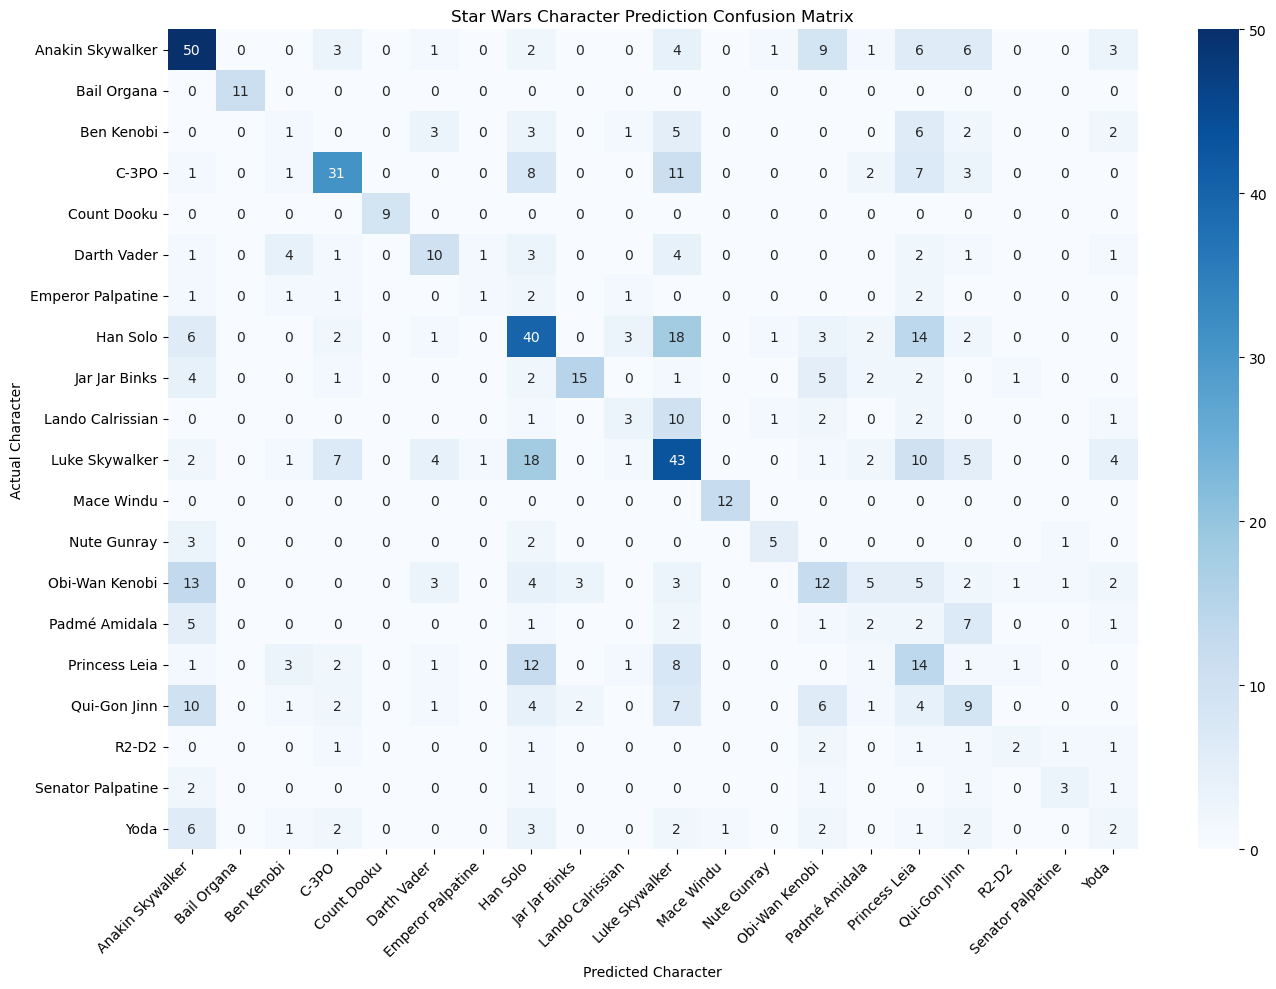

In [198]:
# Creating an actual character v.s predicted character chart
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, 
            annot=True, 
            fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Star Wars Character Prediction Confusion Matrix")
plt.ylabel("Actual Character")
plt.xlabel("Predicted Character")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [199]:
# Listing top 10 most used words for each of the 20 characters
feature_names = vectorizer.get_feature_names_out()

for i, character in enumerate(le.classes_):
    if hasattr(model, 'coef_'):
        top_indices = np.argsort(model.coef_[i])[-10:]
        top_words = [feature_names[j] for j in top_indices]
        print(f"\n{character}:")
        print(f"  Top words: {', '.join(top_words)}")


Anakin Skywalker:
  Top words: subtitled, obiwan, runs, room, quigon, looks, padme, mom, padm, contd

Bail Organa:
  Top words: organas, organas starcruiser, conference, yoda obiwan, speeder, approaches, aides, waiting, yoda, organa

Ben Kenobi:
  Top words: yoda, good friend, evil, always, empire, learn, patience, cannot, luke, force

C-3PO:
  Top words: hurry, im, goodness, going, doomed, wait, master luke, oh, artoo, sir

Count Dooku:
  Top words: nine hundred, nightclub bar, rest droids, nine, rest season, ship, dookus, sail, sail ship, dooku

Darth Vader:
  Top words: son, obiwan, rebel, shuttle, wish, perhaps, felt, admiral, master, emperor

Emperor Palpatine:
  Top words: skywalker, side, boy, longer, turned, good, fleet, yes, friends, young

Han Solo:
  Top words: lando, huh, well, going, hey, got, get, yeah, kid, chewie

Jar Jar Binks:
  Top words: yous, tis, contd, berry, yousa, dissen, da, wesa, jar, mesa

Lando Calrissian:
  Top words: look, done, pirate, wedge, leia, whoa

In [200]:
# Printing the final classification report
distinctive = [
    "Jar Jar Binks",
    "Yoda",
    "C-3PO",
    "Count Dooku",
    "Mace Windu",
    "Darth Vader",
    "R2-D2",
    "Bail Organa",
]

df_distinctive = df_filtered[df_filtered["character"].isin(distinctive)].copy()

le2 = LabelEncoder()
df_distinctive["label"] = le2.fit_transform(df_distinctive["character"])

vectorizer2 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X2 = vectorizer2.fit_transform(df_distinctive["clean_line"])
y2 = df_distinctive["label"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

model2 = LinearSVC(max_iter=2000, random_state=42, class_weight="balanced")
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print(classification_report(y_test2, y_pred2, target_names=le2.classes_, zero_division=0))

               precision    recall  f1-score   support

  Bail Organa       1.00      0.82      0.90        11
        C-3PO       0.70      0.89      0.78        64
  Count Dooku       1.00      1.00      1.00         9
  Darth Vader       0.61      0.61      0.61        28
Jar Jar Binks       0.76      0.67      0.71        33
   Mace Windu       1.00      1.00      1.00        12
        R2-D2       0.67      0.40      0.50        10
         Yoda       0.57      0.36      0.44        22

     accuracy                           0.73       189
    macro avg       0.79      0.72      0.74       189
 weighted avg       0.73      0.73      0.72       189



In [201]:
# Extra information about the model
def predict_character2(line):
    cleaned  = clean_text_no_stops(line)
    features = vectorizer2.transform([cleaned])
    pred     = model2.predict(features)[0]
    return le2.inverse_transform([pred])[0]

print(predict_character2("Do or do not there is no try"))
print(predict_character2("I am your father"))
print(predict_character2("Oh my this is quite dangerous"))
print(predict_character2("Mesa so excited to be here"))

Yoda
Darth Vader
C-3PO
Jar Jar Binks
